# Reactor models

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from majordome.common import RelaxUpdate
from majordome.plug import PlugFlowChainCantera
from majordome.plug import get_reactor_data
from matplotlib import pyplot as plt
from tabulate import tabulate
import cantera as ct
import numpy as np

In [3]:
class ReactorModel:
    """ Wrapper model for creation of a plug flow reactor. """
    def __init__(self, z, V, T_inj=300):       
        self._T_inj = T_inj

        self._sol = sol = ct.Solution("airish.yaml", "air")
        self._sol.TP = T_inj, ct.one_atm

        self._pfr = PlugFlowChainCantera(sol.source, sol.name, z, V)
        self._src = get_reactor_data(self._pfr)

    def add_source(self, *, where, m, X, T=None):
        self._sol.TPX = T or self._T_inj, None, X
        self._src.m[where] = m
        self._src.h[where] = self._sol.h
        self._src.Y[where, :] = self._sol.Y

    def set_power(self, Q):
        self._src.Q[:] = Q

    def solve(self, report=True):
        self._pfr.update(self._src)

        if report:
            print(tabulate([
                ("Total mass flow rate", "g/s", 1000*self._src.m.sum()),
                ("Total external power", "W",   self._src.Q.sum()),
                ("Final temperature ",   "K",   self._pfr.states.T[-1]),
            ], tablefmt="github"))

    def plot(self, *args, **kwargs):
        return self._pfr.quick_plot(*args, **kwargs)

    @property
    def table(self):
        return reactor._pfr.states.to_pandas()

## Single freeboard reactor

In [4]:
def sample_case(l=0.001):
    z = np.arange(l/2, 1.0-l/2+0.1*l, l)
    V = np.full_like(z, np.pi * 0.05**2 * l)

    dilute = slice(np.argmax(z > 0.15), np.argmax(z > 0.40))

    Q = 100_000 * l * (1 - np.exp(-z / 0.3))
    Q[z > z[-1]/2] = 0
    
    reactor = ReactorModel(z, V)
    reactor.add_source(where=0,      m=0.05,  X="N2: 0.79, O2: 0.21")
    reactor.add_source(where=dilute, m=1.0*l, X="AR: 1")
    reactor.set_power(Q)
    reactor.solve()
    return reactor

In [5]:
reactor = sample_case()

|----------------------|-----|-----------|
| Total mass flow rate | g/s |   300     |
| Total external power | W   | 25666.3   |
| Final temperature    | K   |   427.412 |


In [6]:
reactor.table.head().T

,0,1,2,3,4
z_cell,0.000500,0.001500,0.002500,0.003500,0.004500
V_cell,0.000008,0.000008,0.000008,0.000008,0.000008
Q_cell,0.166528,0.498752,0.829871,1.159888,1.488806
m_cell,0.000009,0.000009,0.000009,0.000009,0.000009
mdot_cell,0.050000,0.050000,0.050000,0.050000,0.050000
T,300.000000,300.009876,300.026307,300.049274,300.078753
density,1.171971,1.171932,1.171868,1.171778,1.171663
Y_O2,0.232909,0.232909,0.232909,0.232909,0.232909
Y_N2,0.767091,0.767091,0.767091,0.767091,0.767091
Y_AR,0.000000,0.000000,0.000000,0.000000,0.000000


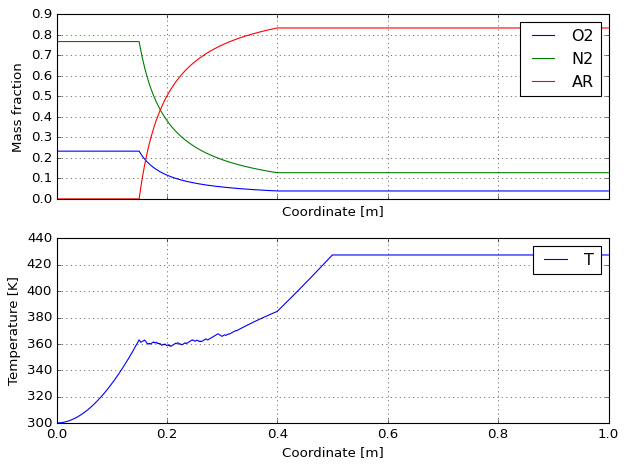

In [7]:
reactor.plot().resize(8, 6)

|----------------------|-----|-----------|
| Total mass flow rate | g/s |   300     |
| Total external power | W   | 25666.3   |
| Final temperature    | K   |   446.921 |


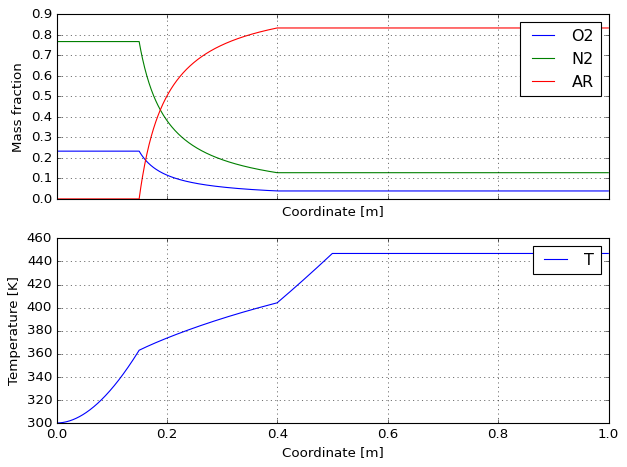

In [8]:
reactor.solve()
reactor.plot().resize(8, 6)

## Counter-current freeboard reactors

In [9]:
m = 0.1
L = 0.02
R = 0.05

h = 100.0
Sc = 2.0 * np.pi * R * L
Vc = 1.0 * np.pi * R**2 * L
X = "N2: 0.79, O2: 0.21"

z = np.arange(L/2, 1.0-0.99*L/2, L)
V = np.full_like(z, Vc)

r1 = ReactorModel(z, V)
r2 = ReactorModel(z, V)

r1.add_source(where=0, m=m*0.1,  X=X, T=300)
r2.add_source(where=0, m=m*1.0,  X=X, T=600)

dilute = slice(np.argmax(z > 0.15), np.argmax(z > 0.20) + 1)
r2.add_source(where=dilute, m=0.01,  X="AR: 1", T=450)

r1.solve(report=False)
r2.solve(report=True)

|----------------------|-----|---------|
| Total mass flow rate | g/s | 130     |
| Total external power | W   |   0     |
| Final temperature    | K   | 582.706 |


In [10]:
q = np.zeros_like(z)
relax = RelaxUpdate(q, alpha=0.8)

h = 200.0

count = 0
patience = 3
max_iters = 50
T1_last = np.inf
T2_last = np.inf

T1 = r1._pfr.states.T
T2 = r2._pfr.states.T

alternate = True
alternate = False

for k in range(max_iters):
    if alternate:
        q[:] = relax(Sc * h * (T1 - T2[::-1]))
        r1.set_power(-1 * q)
        r1.solve(report=False)
        T1 = r1._pfr.states.T
    
        q[:] = relax(Sc * h * (T1 - T2[::-1]))
        r2.set_power(q[::-1])
        r2.solve(report=False)
        T2 = r2._pfr.states.T
    else:
        T1 = r1._pfr.states.T
        T2 = r2._pfr.states.T
    
        q[:] = relax(Sc * h * (T1 - T2[::-1]))
        
        r1.set_power(-1 * q)
        r2.set_power(q[::-1])
        
        r1.solve(report=False)
        r2.solve(report=False)

    c1 = np.isclose(T1[-1], T1_last)
    c2 = np.isclose(T2[-1], T2_last)
    
    T1_last = T1[-1]
    T2_last = T2[-1]

    if c1 and c2:
        count += 1
        
    if c1 and c2 and count >= patience:
        print(f"Converged after {k} iterations")
        break

Converged after 33 iterations


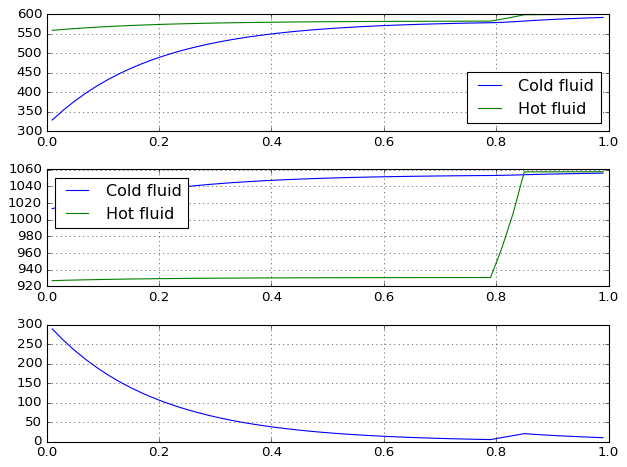

In [11]:
T1 = r1._pfr.states.T
T2 = r2._pfr.states.T[::-1]

cp1 = r1._pfr.states.cp_mass
cp2 = r2._pfr.states.cp_mass[::-1]

plt.close("all")
plt.style.use("classic")
plt.figure(figsize=(8, 6), facecolor="w")

plt.subplot(311)
plt.plot(z, T1, label="Cold fluid")
plt.plot(z, T2, label="Hot fluid")
plt.grid(linestyle=":")
plt.legend(loc=4)

plt.subplot(312)
plt.plot(z, cp1, label="Cold fluid")
plt.plot(z, cp2, label="Hot fluid")
plt.grid(linestyle=":")
plt.legend(loc=2)

plt.subplot(313)
plt.plot(z, -q)
plt.grid(linestyle=":")

plt.tight_layout()

In [12]:
r1.solve(report=True)

|----------------------|-----|----------|
| Total mass flow rate | g/s |   10     |
| Total external power | W   | 3007.06  |
| Final temperature    | K   |  591.899 |


In [13]:
r2.solve(report=True)

|----------------------|-----|-----------|
| Total mass flow rate | g/s |   130     |
| Total external power | W   | -3007.06  |
| Final temperature    | K   |   558.755 |


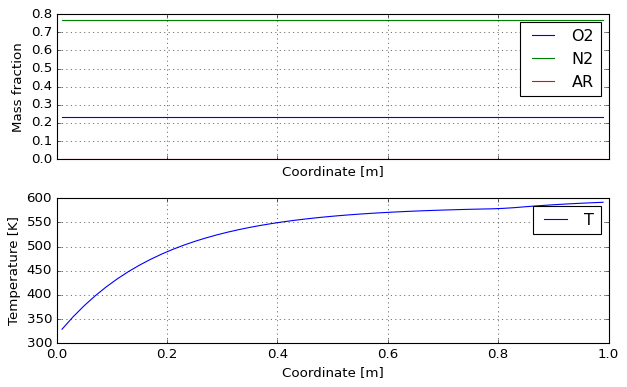

In [14]:
r1.plot().resize(8, 5)

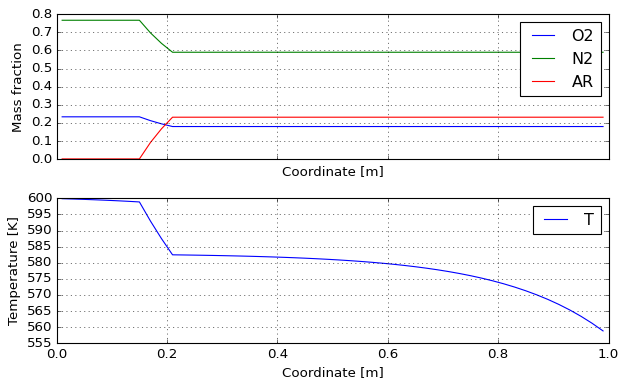

In [15]:
r2.plot().resize(8, 5)